# Tutorial: Converting CommonRoad Scenarios to SUMO Networks
This tutorial explains how to convert a **recorded** CommonRoad scenario XML file to [SUMO](https://sumo.dlr.de/docs/index.html) network files. This is required, as the **interactive** behaviours of other traffic participants are later simulated using the SUMO simulator. A **recorded** scenario is one in which all the traffic participants follow pre-recorded trajectories, whereas in an **interactive** scenario, those trajectories vary depending on the input trajectory of the ego vehicle.

## 0. Preparation
Before you proceed with this tutorial, we assume that:
* you have gone through the tutorials on [CommonRoad Input-Output](https://commonroad.in.tum.de/tutorial-commonroad-interface) and have a basic understanding of the CommonRoad scenarios.
* you have gone through the tutorials on [SUMO (Simulation of Urban MObility)](https://sumo.dlr.de/docs/Tutorials.html) and have a basic understanding of the SUMO network.
* you have successfully installed all necessary modules for the interactive benchmark by running the installation script.

If you encountered an issue, feel free to raise it in the CommonRoad [forum](https://commonroad.in.tum.de/forum/c/interactive-scenarios/15).

## 1. CommonRoad Scenario
To start with, a CommonRoad XML file consists of a **Scenario** and a **PlanningProblemSet**:

* A **Scenario** represents the environment, which includes a **LaneletNetwork** and a set of **DynamicObstacle** and **StaticObstacle**.
    * A **LaneletNetwork** consists of a set of lane segments (**Lanelets**) that can be connected arbitrarily.
* A **PlanningProblemSet** contains one **PlanningProblem** for every ego vehicle in the **Scenario**, which in turn has an **initial position** and a to-be-reached **GoalRegion**.

Below, we simply load an existing scenario.

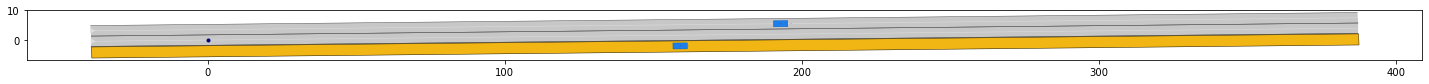

In [1]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

import os
import matplotlib.pyplot as plt
from IPython import display

# import classes and functions for reading xml file and visualizing commonroad objects
from commonroad.common.file_reader import CommonRoadFileReader
from commonroad.visualization.draw_dispatch_cr import draw_object

# generate path of the file to be read
path_file = "./example_scenarios/cr_scenario/DEU_A9-2_1_T-1.xml"

# read in the scenario and planning problem set
scenario, planning_problem_set = CommonRoadFileReader(path_file).open()

# plot the scenario for 40 time steps, here each time step corresponds to 0.1 second

for i in range(0, len(scenario.obstacles[0].prediction.trajectory.state_list)): 
    # uncomment the following line to clear previous graph for better visualization
    display.clear_output(wait=True)
    plt.figure(figsize=(25, 10))
    # plot the scenario for each time step
    draw_object(scenario, draw_params={'time_begin': i})
    # plot the planning problem set
    draw_object(planning_problem_set)
    plt.gca().set_aspect('equal')
    plt.show()

## 2. SUMO Network
A SUMO network with the name 'MapName' usually consists of the following files stored in a folder named 'MapName': 

* **nodes.net.xml**: a SUMO node file defining all the nodes in the network.
* **edges.net.xml**: a SUMO edge file defining the edges connecting the nodes in the network.
* **MapName.net.xml**: a net file defining the SUMO network. A network can either be converted from nodes and edges, or be created by using SUMO-GUI.
* **MapName.vehicles.rou.xml**: a SUMO route file defining the vehicles and their routes in the network. 
* **MapName.sumo.cfg**: a SUMO configuration file defining the configurations of a SUMO simulation.
* **MapName.add.xml**: a file sotring additional parameters, such as the acceleration and deceleration parameters of a vehicle model.

## 3. Converting CommonRoad Scenarios to SUMO Networks

To convert a CommonRoad sceanrio to SUMO network, simply call the function **convert_scenario()** with the following arguments:
* **cr_scenario_path**: path to the CommonRoad scenario XML file to be converted. 
* **output_folder_path**: path to store the conversion outputs. After the conversion, a folder storing all the converted files will be created in this path. 
* **config_type**: configuration file used for the conversion. Available configuration files are located in the "configuration/" folder. **Default value**: CONFIG_TYPE.SUMO_CONFIG_1
* **creating_video**: a boolean value indicating whether a video file of the SUMO simulated should be created or not. **Default value**: False. (At th moment this functionality is not implemented yet, thus setting this to true will raise **NotImplementedError**.)

After the conversion, the scenario drops its previous suffix 'T-X' (indicating it has trajectories as predictions), and obtains the new suffix 'I-X-Y', indicating that it is using the config X and Y ...?

In [ ]:
from scenario_converter.convert_scenarios import convert_scenario
from configuration import CONFIG_TYPE

# prepare required arguments
cr_scenario_path  = "./example_scenarios/cr_scenario/DEU_A9-2_1_T-1.xml"
output_folder_path = "./example_scenarios/output/tutorial_1"
config_type = CONFIG_TYPE.SUMO_CONFIG_1
creating_video = False

# convert the sceanrio
convert_scenario(cr_scenario_path  = cr_scenario_path,
                output_folder_path = output_folder_path,
                config_type = config_type,
                creating_video = creating_video)


You should see a list of files created and stored in the output folder.

In [4]:
from os import listdir
from os.path import isfile, join

output_path = "./example_scenarios/output/tutorial_1/DEU_A9-2_1_I-1-1"
list_files = [f for f in listdir(output_path) if isfile(join(output_path, f))]
print(list_files)

['_connections.net.xml', 'edges.net.xml', 'DEU_A9-2_1_I-1-1.net.xml', 'nodes.net.xml', 'DEU_A9-2_1_I-1-1.vehicles.rou.xml', '_tll.net.xml', 'DEU_A9-2_1_I-1-1.cr.xml', 'DEU_A9-2_1_I-1-1.pedestrians.rou.xml', 'simulation_config.p', 'DEU_A9-2_1_I-1-1.sumo.cfg', 'DEU_A9-2_1_I-1-1.add.xml']


We briefly explain what has happended during the conversion:
* The CommonRoad scenario **DEU_A9-2_1_T-1.xml** is reduced to only store the initial states of all traffic participants, and is saved as **DEU_A9-2_1_I-1-1.cr.xml**.
* The lanelet network within the scenario is converted to SUMO network, and is saved as **nodes.net.xml**, **edges.net.xml**, and **DEU_A9-2_1_I-1-1.net.xml**.
* The trajcetories of traffic participants in the original scenario is converted to SUMO routes, and saved as **DEU_A9-2_1_I-1-1.vehicle.rou.xml** and **DEU_A9-2_1_I-1-1.sumo.cfg**.
* Lastly, the configuration of the simulation is saved as **simulation_config.p**.


We are now ready to use the converted SUMO network files to simulate the behaviour of traffic participants. In the next tutorial, we demonstrate the interaction between the traffic participants and the ego vehicle.